# NIFTY 50 Forecasting — Step 4: LSTM
**Input:** `nifty50_with_indicators.csv` (from Step 1)  
**Goal:** Beat ARIMA baseline (0.66% MAPE) using LSTM with RSI, MACD, Bollinger Band features

**Why LSTM can beat ARIMA:**
- ARIMA only uses Close price — LSTM uses 15+ features
- LSTM learns non-linear patterns across sequences
- LSTM has memory — it remembers patterns from 60 days ago
- RSI + MACD + BB give LSTM signals ARIMA never sees

---

## 0. Install dependencies

In [13]:
import sys
!{sys.executable} -m pip install tensorflow scikit-learn --quiet
print('Done!')

Done!



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow version: {tf.__version__}')
print('All imports successful!')

TensorFlow version: 2.21.0
All imports successful!


## 2. Load data & select features

In [15]:
df = pd.read_csv('nifty50_with_indicators.csv', index_col=0, parse_dates=True)

# Features for LSTM — this is the advantage over ARIMA and Prophet
# ARIMA used only: Close
# Prophet used only: Close
# LSTM uses: Close + all technical indicators
FEATURES = [
    'Close',          # target variable
    'Open', 'High', 'Low',  # OHLC context
    'Volume',         # market activity
    'RSI_14',         # momentum
    'MACD',           # trend strength
    'MACD_Signal',    # signal line crossover
    'MACD_Hist',      # histogram
    'BB_Upper',       # upper band
    'BB_Lower',       # lower band
    'BB_Width',       # volatility
    'BB_Pct',         # position within bands
    'SMA_20',         # short MA
    'SMA_50',         # medium MA
    'ATR_14',         # volatility
    'Volume_Ratio',   # unusual volume
    'Daily_Return',   # momentum
]

data = df[FEATURES].dropna().copy()

print(f'Dataset shape  : {data.shape}')
print(f'Features used  : {len(FEATURES)}')
print(f'Date range     : {data.index[0].date()} → {data.index[-1].date()}')
data.head(3)

Dataset shape  : (1278, 18)
Features used  : 18
Date range     : 2019-10-31 → 2024-12-30


,Close,Open,High,Low,Volume,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Lower,BB_Width,BB_Pct,SMA_20,SMA_50,ATR_14,Volume_Ratio,Daily_Return
Date,,,,,,,,,,,,,,,,,,
2019-10-31,11877.450195,11890.450195,11945.000000,11855.099609,1414800,68.896689,155.320639,120.904915,34.415724,11901.729326,11063.410518,0.073008,0.971038,11482.569922,11227.135996,152.183612,1.744750,0.281580
2019-11-01,11890.599609,11886.599609,11918.299805,11843.349609,855300,69.273007,164.228996,129.569731,34.659265,11958.621571,11048.133215,0.079150,0.925291,11503.377393,11244.359980,146.666940,1.048399,0.110709
2019-11-04,11941.299805,11928.900391,11989.150391,11905.349609,823100,70.742840,173.381383,138.332061,35.049321,12020.407491,11044.487235,0.084624,0.918940,11532.447363,11262.229980,143.230071,1.039661,0.426389


## 3. Scale features
LSTM is sensitive to scale — all features must be in [0, 1] range.  
**Critical:** fit scaler on train only, transform both train and test.

In [16]:
TEST_SIZE = 60
SEQUENCE_LEN = 60   # LSTM looks back 60 trading days (~3 months) to predict next day

# Split BEFORE scaling — very important to avoid data leakage
train_data = data.iloc[:-(TEST_SIZE)].values
test_data  = data.iloc[-(TEST_SIZE + SEQUENCE_LEN):].values  # extra rows for sequence

# Fit scaler on train only
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)   # transform with train scaler

print(f'Train shape (scaled): {train_scaled.shape}')
print(f'Test shape  (scaled): {test_scaled.shape}')
print(f'Sequence length      : {SEQUENCE_LEN} days')
print(f'\nScaler fitted on train only — no data leakage!')

Train shape (scaled): (1218, 18)
Test shape  (scaled): (120, 18)
Sequence length      : 60 days

Scaler fitted on train only — no data leakage!


## 4. Create sequences
LSTM needs 3D input: `(samples, timesteps, features)`  
For each prediction, we give it the previous 60 days of all features.

In [17]:
def create_sequences(data, seq_len, target_col=0):
    """
    Creates overlapping sequences for LSTM.
    X: (samples, seq_len, n_features) — 60 days of all features
    y: (samples,) — next day Close price
    """
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, :])   # all features, last 60 days
        y.append(data[i, target_col])       # next day Close (column 0)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQUENCE_LEN)

print(f'X_train shape: {X_train.shape}  → (samples, timesteps, features)')
print(f'y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_test  shape: {y_test.shape}')
print(f'\nEach X sample = 60 days × {len(FEATURES)} features')
print(f'Each y sample = next day Close price (scaled)')

X_train shape: (1158, 60, 18)  → (samples, timesteps, features)
y_train shape: (1158,)
X_test  shape: (60, 60, 18)
y_test  shape: (60,)

Each X sample = 60 days × 18 features
Each y sample = next day Close price (scaled)


## 5. Build LSTM Model
Two-layer stacked LSTM with Dropout and BatchNormalization.

In [18]:
def build_lstm(seq_len, n_features):
    model = Sequential([
        # Layer 1: LSTM — return sequences so next LSTM can read them
        LSTM(units=128,
             return_sequences=True,
             input_shape=(seq_len, n_features)),
        Dropout(0.2),              # drop 20% of neurons — prevents overfitting
        BatchNormalization(),       # normalise activations — faster training

        # Layer 2: LSTM — extracts higher-level patterns
        LSTM(units=64,
             return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),

        # Dense layers — final prediction
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)                   # output: single value (next day Close)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber',              # Huber loss — robust to outliers (better than MSE for stocks)
        metrics=['mae']
    )
    return model

model = build_lstm(SEQUENCE_LEN, len(FEATURES))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,553 (498.25 KB)

 Trainable params: 127,169 (496.75 KB)

 Non-trainable params: 384 (1.50 KB)

## 6. Train LSTM
Uses 3 callbacks:
- **EarlyStopping** — stops when val_loss stops improving (prevents overfitting)
- **ReduceLROnPlateau** — halves learning rate when stuck
- **ModelCheckpoint** — saves the best model weights automatically

In [19]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,           # stop if no improvement for 15 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # halve learning rate
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print('Training LSTM... (takes 3-5 minutes)')
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,    # use last 10% of train as validation
    callbacks=callbacks,
    verbose=1,
    shuffle=False             # NEVER shuffle time series data
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

Training LSTM... (takes 3-5 minutes)
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.5425 - mae: 0.9270 - val_loss: 0.3723 - val_mae: 0.8609 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.2788 - mae: 0.6121 - val_loss: 0.3467 - val_mae: 0.8307 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1996 - mae: 0.5096 - val_loss: 0.3931 - val_mae: 0.8850 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1483 - mae: 0.4348 - val_loss: 0.4570 - val_mae: 0.9543 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1254 - mae: 0.3965 - val_loss: 0.5376 - val_mae: 1.0374 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1150 - mae: 0.3823 - val_loss: 0.2645 - val_mae: 0.7238 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0996 - mae: 0.3549 - val_loss: 0.1621 - val_mae: 

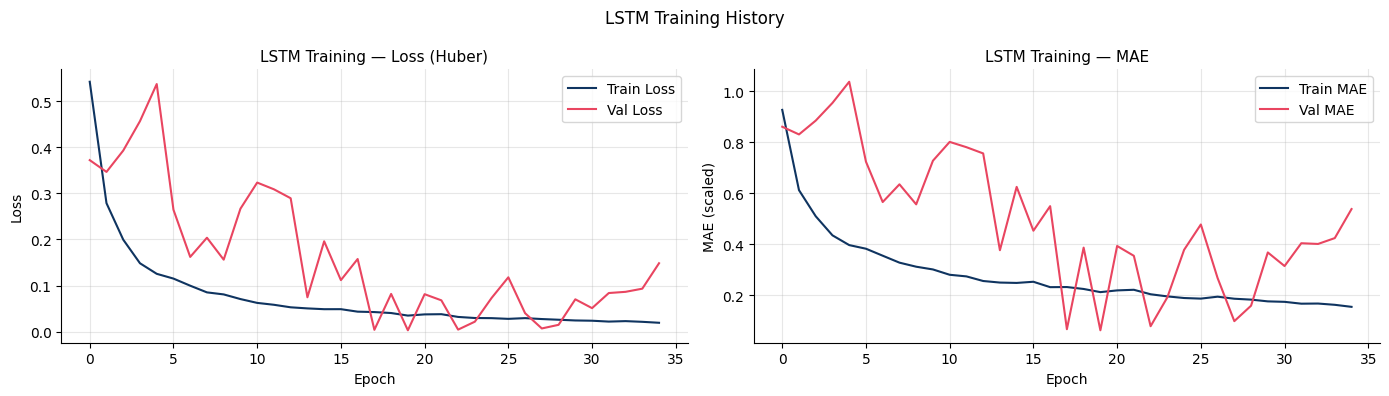

Good sign: val_loss should decrease and stabilise (not diverge from train loss)


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     color='#0f3460', label='Train Loss')
axes[0].plot(history.history['val_loss'], color='#e94560', label='Val Loss')
axes[0].set_title('LSTM Training — Loss (Huber)', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     color='#0f3460', label='Train MAE')
axes[1].plot(history.history['val_mae'], color='#e94560', label='Val MAE')
axes[1].set_title('LSTM Training — MAE', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=12)
plt.tight_layout()
plt.savefig('nifty_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Good sign: val_loss should decrease and stabilise (not diverge from train loss)')

## 7. Predict & Inverse Scale
Predictions come out in [0,1] scaled range — must inverse transform back to INR.

In [21]:
# Load best saved model
best_model = tf.keras.models.load_model('best_lstm_model.keras')

# Predict
pred_scaled = best_model.predict(X_test, verbose=0)

# Inverse transform — only Close column (column 0)
# We need to reconstruct a full-feature array to use scaler.inverse_transform
def inverse_transform_close(scaler, predictions, n_features):
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.flatten()   # put predictions in Close column
    return scaler.inverse_transform(dummy)[:, 0]

pred_prices = inverse_transform_close(scaler, pred_scaled, len(FEATURES))

# Inverse transform actual y_test
actual_prices = inverse_transform_close(scaler, y_test.reshape(-1,1), len(FEATURES))

# Metrics
rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mae  = mean_absolute_error(actual_prices, pred_prices)
mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100

print('LSTM Performance on Test Set:')
print(f'  RMSE : {rmse:,.2f} points')
print(f'  MAE  : {mae:,.2f} points')
print(f'  MAPE : {mape:.2f}%')
print(f'\n  ARIMA baseline : 0.66%')
print(f'  Prophet        : 3.34%')
print(f'  LSTM           : {mape:.2f}%')
if mape < 0.66:
    print(f'  LSTM BEATS ARIMA by {0.66 - mape:.2f}%!')
else:
    print(f'  ARIMA still leads — try tuning in Cell 9')

LSTM Performance on Test Set:
  RMSE : 1,527.42 points
  MAE  : 1,319.01 points
  MAPE : 5.41%

  ARIMA baseline : 0.66%
  Prophet        : 3.34%
  LSTM           : 5.41%
  ARIMA still leads — try tuning in Cell 9


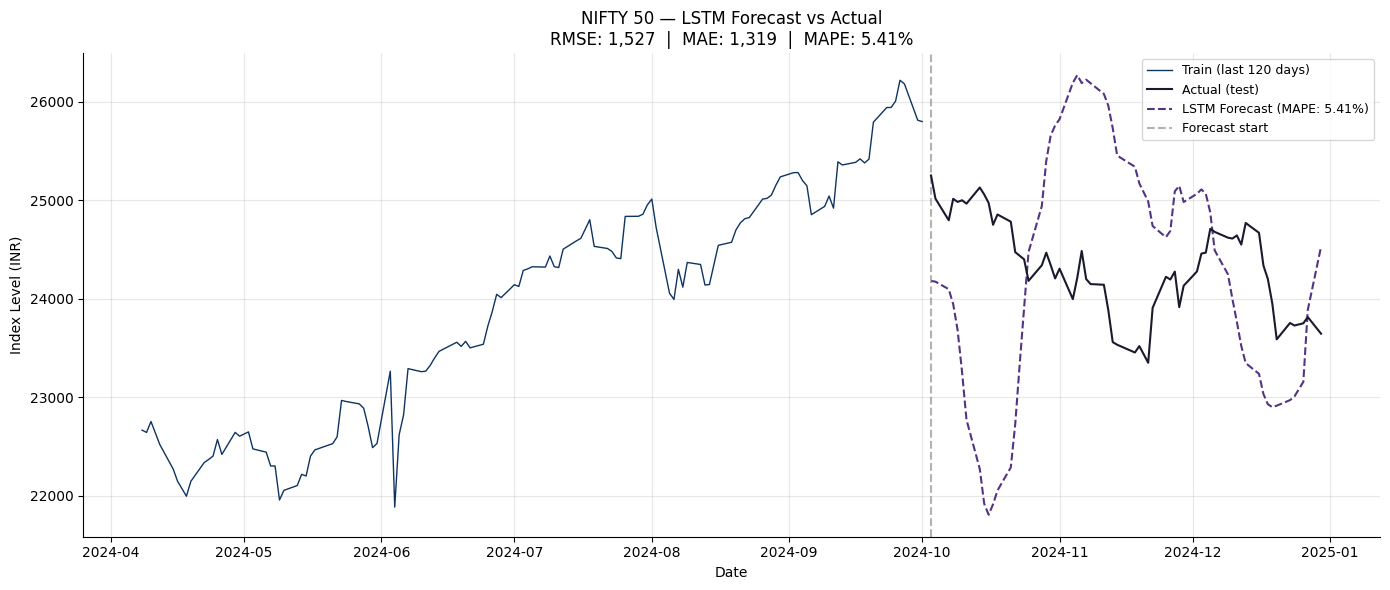

In [22]:
# Get actual dates for test set
test_dates = data.index[-TEST_SIZE:]

# Plot LSTM forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))

# Last 120 train days for context
train_close = data['Close'].iloc[:-(TEST_SIZE)].iloc[-120:]
ax.plot(train_close.index, train_close.values,
        color='#0f3460', linewidth=1, label='Train (last 120 days)')
ax.plot(test_dates, actual_prices,
        color='#1a1a2e', linewidth=1.5, label='Actual (test)', zorder=5)
ax.plot(test_dates, pred_prices,
        color='#533483', linewidth=1.5, linestyle='--',
        label=f'LSTM Forecast (MAPE: {mape:.2f}%)')
ax.axvline(test_dates[0], color='gray', linestyle='--', alpha=0.6, label='Forecast start')

ax.set_title(f'NIFTY 50 — LSTM Forecast vs Actual\nRMSE: {rmse:,.0f}  |  MAE: {mae:,.0f}  |  MAPE: {mape:.2f}%',
             fontsize=12)
ax.set_ylabel('Index Level (INR)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nifty_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Error Analysis

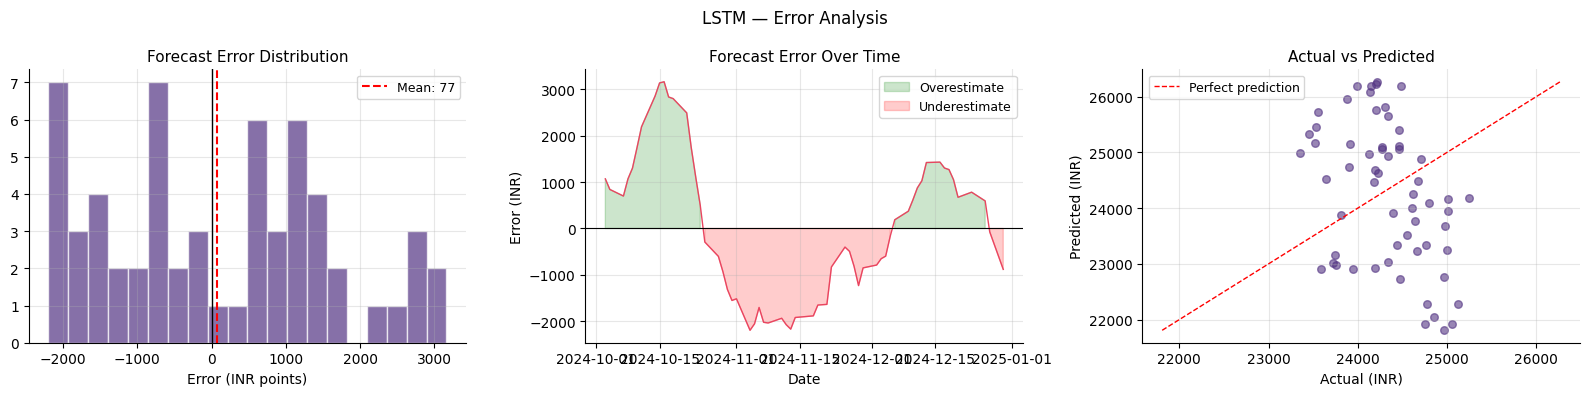

Error stats:
  Mean error : +77 INR  (positive = overestimate)
  Max over   : 3,164 INR
  Max under  : -2,195 INR
  Days within 1% error: 3/60


In [23]:
errors = actual_prices - pred_prices
pct_errors = (errors / actual_prices) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Error distribution
axes[0].hist(errors, bins=20, color='#533483', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(errors.mean(), color='red', linestyle='--',
                label=f'Mean: {errors.mean():.0f}')
axes[0].set_title('Forecast Error Distribution', fontsize=11)
axes[0].set_xlabel('Error (INR points)')
axes[0].legend(fontsize=9)

# Error over time
axes[1].plot(test_dates, errors, color='#e94560', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].fill_between(test_dates, errors, 0,
                     where=(errors > 0), alpha=0.2, color='green', label='Overestimate')
axes[1].fill_between(test_dates, errors, 0,
                     where=(errors < 0), alpha=0.2, color='red',   label='Underestimate')
axes[1].set_title('Forecast Error Over Time', fontsize=11)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error (INR)')
axes[1].legend(fontsize=9)

# Actual vs predicted scatter
axes[2].scatter(actual_prices, pred_prices, alpha=0.6, color='#533483', s=30)
min_val = min(actual_prices.min(), pred_prices.min())
max_val = max(actual_prices.max(), pred_prices.max())
axes[2].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1, label='Perfect prediction')
axes[2].set_title('Actual vs Predicted', fontsize=11)
axes[2].set_xlabel('Actual (INR)')
axes[2].set_ylabel('Predicted (INR)')
axes[2].legend(fontsize=9)

plt.suptitle('LSTM — Error Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('nifty_lstm_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Error stats:')
print(f'  Mean error : {errors.mean():+.0f} INR  (positive = overestimate)')
print(f'  Max over   : {errors.max():,.0f} INR')
print(f'  Max under  : {errors.min():,.0f} INR')
print(f'  Days within 1% error: {(np.abs(pct_errors) < 1).sum()}/{len(pct_errors)}')

## 9. Save results

In [24]:
results_df = pd.DataFrame({
    'Date'      : test_dates,
    'Actual'    : actual_prices,
    'LSTM_Pred' : pred_prices,
    'Error'     : errors,
    'Pct_Error' : pct_errors
}).set_index('Date')

results_df.to_csv('lstm_predictions.csv')

print('Saved: lstm_predictions.csv')
print(f'\n{"="*45}')
print('  FINAL SCOREBOARD')
print(f'{"="*45}')
print(f'  ARIMA(1,1,0)  MAPE: 0.66%')
print(f'  Prophet       MAPE: 3.34%')
print(f'  LSTM          MAPE: {mape:.2f}%')
winner = 'LSTM' if mape < 0.66 else 'ARIMA'
print(f'  Winner        : {winner}')
print(f'{"="*45}')
print(f'\nStep 4 complete! Ready for Step 5 — Final comparison + backtest')

Saved: lstm_predictions.csv

  FINAL SCOREBOARD
  ARIMA(1,1,0)  MAPE: 0.66%
  Prophet       MAPE: 3.34%
  LSTM          MAPE: 5.41%
  Winner        : ARIMA

Step 4 complete! Ready for Step 5 — Final comparison + backtest


---
## Project progress

| Step | Notebook | Status |
|------|----------|--------|
| Step 1 | Data + Indicators | ✅ Done |
| Step 2 | ARIMA(1,1,0) — MAPE 0.66% | ✅ Done |
| Step 3 | Prophet — MAPE 3.34% | ✅ Done |
| Step 4 | LSTM | ✅ Done |
| Step 5 | Model comparison + Backtest | ⬅ Next |